# Seaborn Data Visualization

Seaborn is a Python library built on Matplotlib for creating attractive statistical plots with less code.
This notebook shows common Seaborn plots and explains when to use each one.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load example dataset provided by Seaborn
# The 'tips' dataset contains restaurant bill and tip amounts
tips = sns.load_dataset('tips')
print('First rows of the tips dataset:')
display(tips.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Scatter Plot
Use scatter plots to show the relationship between two continuous variables, such as bill amount and tip amount. Use them when you want to see patterns, clusters, or whether one number grows with another.

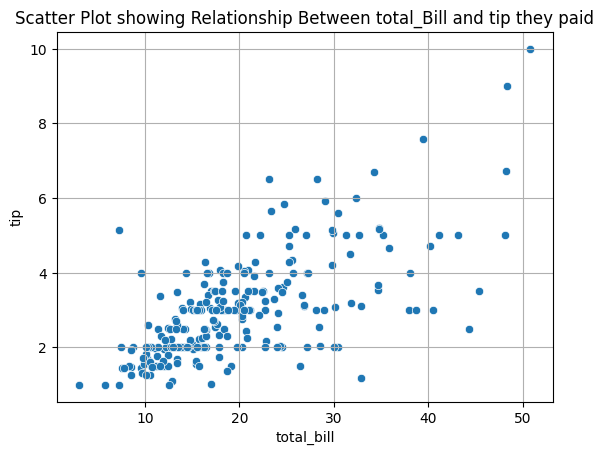

In [ ]:
# Scatter plot shows how tip changes with total bill amount
sns.scatterplot(x='total_bill', y='tip', data=tips)
plt.title('Tip vs Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

## Line Plot
Line plots are useful for showing trends or changes in one variable as another variable increases. Use them when you want to follow a value over an order or size.

Text(0.5, 1.0, 'Line Plot of total_bill and Size')

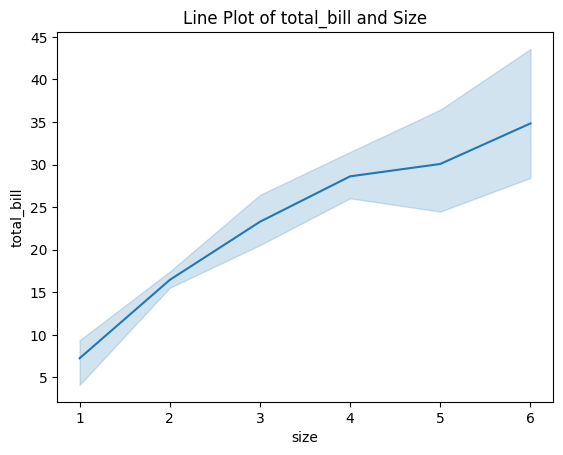

In [ ]:
# Line plot shows average total bill by party size
sns.lineplot(x='size', y='total_bill', data=tips)
plt.title('Total Bill by Party Size')
plt.xlabel('Party Size')
plt.ylabel('Total Bill')
plt.show()

## Bar Plot
Bar plots compare values across categories, such as average bill amount per day. Use them when you want a clear comparison of groups side by side.

Text(0.5, 1.0, 'Bar Plot of total_bill and day')

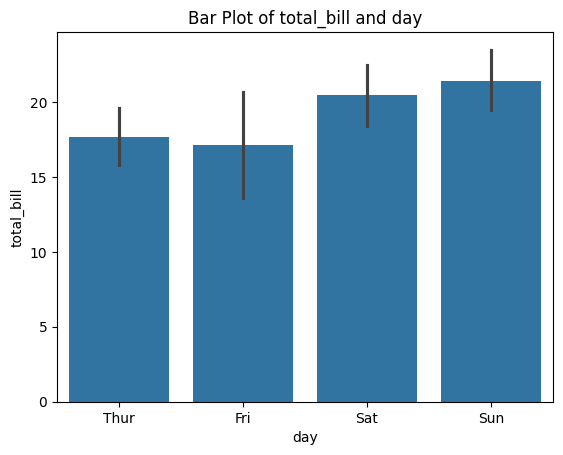

In [ ]:
# Bar plot shows average total bill for each day of the week
sns.barplot(x='day', y='total_bill', data=tips)
plt.title('Average Total Bill by Day')
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.show()

## Box Plot
Box plots show a variable's distribution and highlight outliers across categories. Use them when you need to compare spread, median, and outliers between groups.

<Axes: xlabel='day', ylabel='total_bill'>

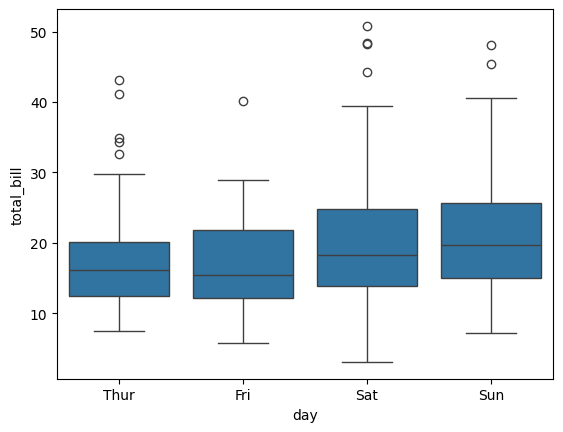

In [ ]:
# Box plot helps compare total bill distribution by day
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('Total Bill Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Total Bill')
plt.show()

## Violin Plot
Violin plots combine distribution shape and summary statistics to compare categories. Use them when you want to see the full distribution and compare it across groups.

<Axes: xlabel='day', ylabel='total_bill'>

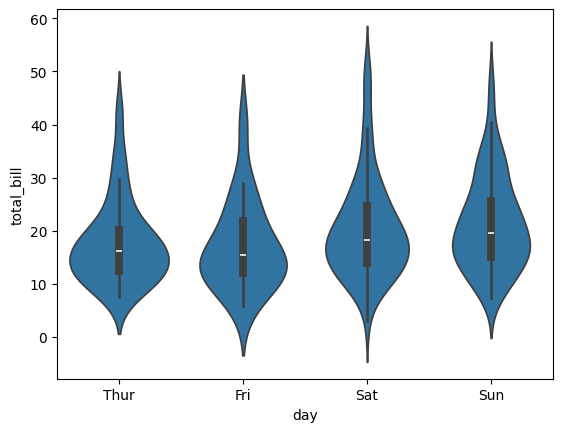

In [ ]:
# Violin plot shows the density and distribution of total bill by day
sns.violinplot(x='day', y='total_bill', data=tips)
plt.title('Total Bill Density by Day')
plt.xlabel('Day')
plt.ylabel('Total Bill')
plt.show()

## Histogram
Histograms show how values are distributed over bins for one numeric variable. Use them when you want to understand the shape and spread of a single numeric feature.

<Axes: xlabel='total_bill', ylabel='Count'>

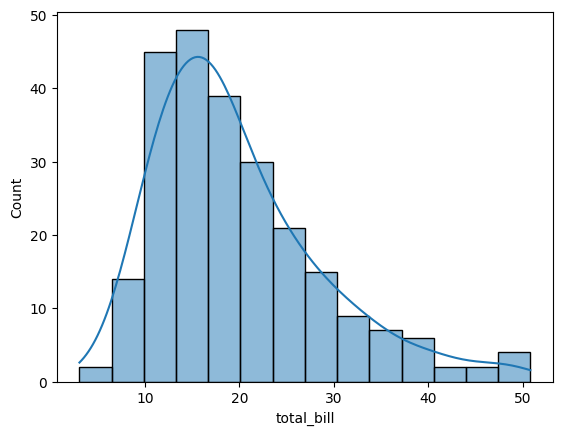

In [ ]:
# Histogram shows the distribution of the total bill amounts
sns.histplot(tips['total_bill'], kde=True)
plt.title('Total Bill Distribution')
plt.xlabel('Total Bill')
plt.ylabel('Count')
plt.show()

## KDE Plot
KDE plots estimate the probability density of a variable and show the shape of its distribution. Use them when you want a smooth view of where values are concentrated.

<Axes: xlabel='total_bill', ylabel='Density'>

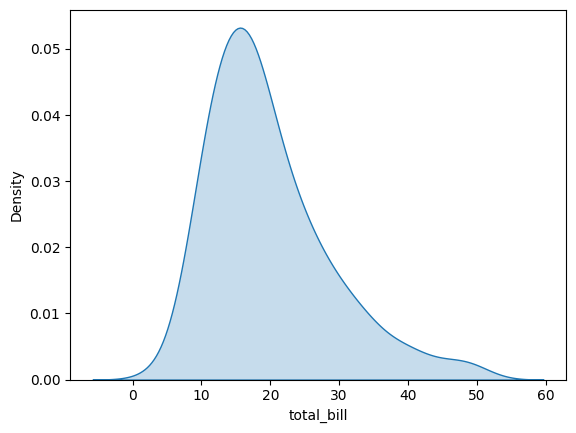

In [ ]:
# KDE plot shows the smoothed distribution of total bill values
sns.kdeplot(tips['total_bill'], fill=True)
plt.title('Total Bill Density Estimate')
plt.xlabel('Total Bill')
plt.ylabel('Density')
plt.show()

## Pair Plot
Pair plots help visualize relationships across multiple numeric variables in one grid. Use them when you want a quick overview of how many variables relate to each other.

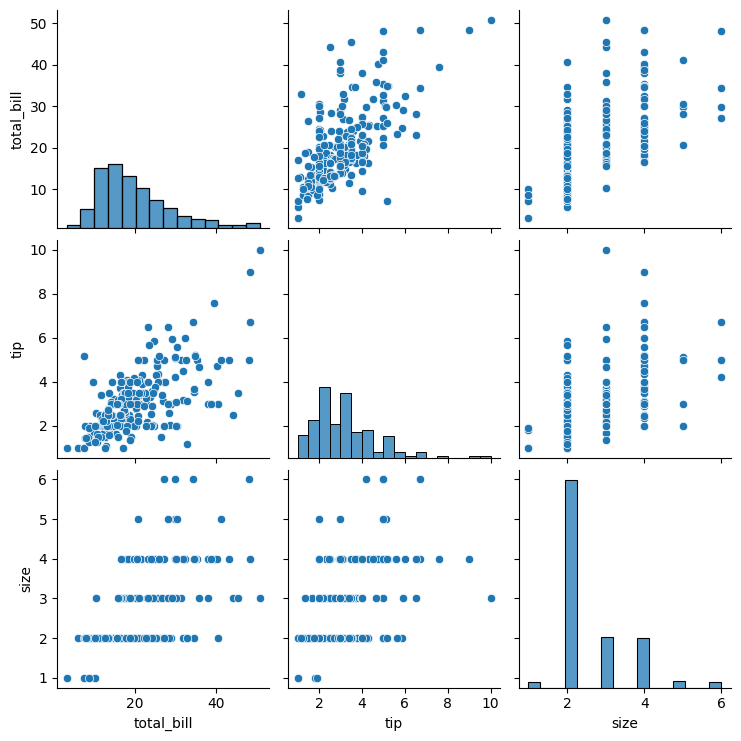

In [ ]:
# Pair plot shows scatter plots and distributions for multiple variables
sns.pairplot(data=tips)
plt.suptitle('Pairwise Relationships in Tips Dataset', y=1.02)
plt.show()

## Heatmap
Heatmaps visualize matrix-style data such as correlation between variables. Use them when you want to spot strong positive or negative relationships quickly.

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

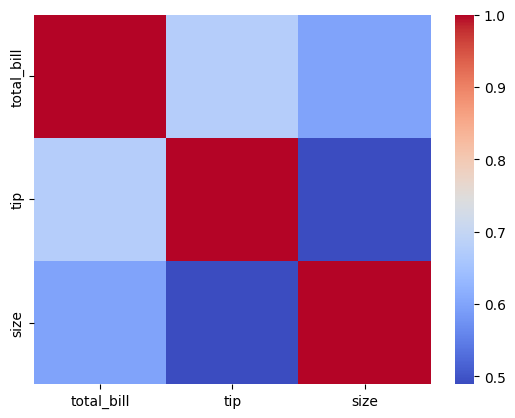

In [ ]:
# Compute correlation matrix for numeric columns
corr = tips[['total_bill', 'tip', 'size']].corr()
print('Correlation matrix:')
display(corr)

# Heatmap makes it easy to spot strong positive or negative correlations
sns.heatmap(data=corr, cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Sales Data Example
Compare Matplotlib and Seaborn for the same aggregated bar chart.

In [ ]:
import pandas as pd

# Load sales data to compare aggregation and plotting styles
sales = pd.read_csv('sales_data.csv')
print('Sales data preview:')
display(sales.head())

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


<BarContainer object of 6 artists>

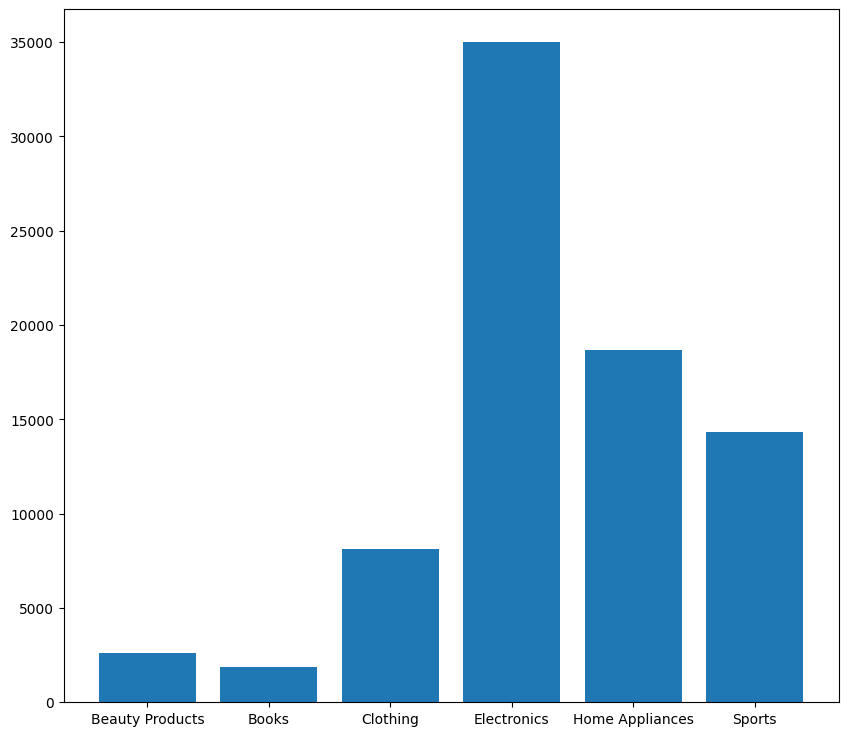

In [ ]:
# Matplotlib requires explicit aggregation before plotting
plt.figure(figsize=(10, 5))
group_revenue = sales.groupby('Product Category')['Total Revenue'].sum().reset_index()
plt.bar(group_revenue['Product Category'], group_revenue['Total Revenue'])
plt.title('Total Revenue by Product Category (Matplotlib)')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='Product Category', ylabel='Total Revenue'>

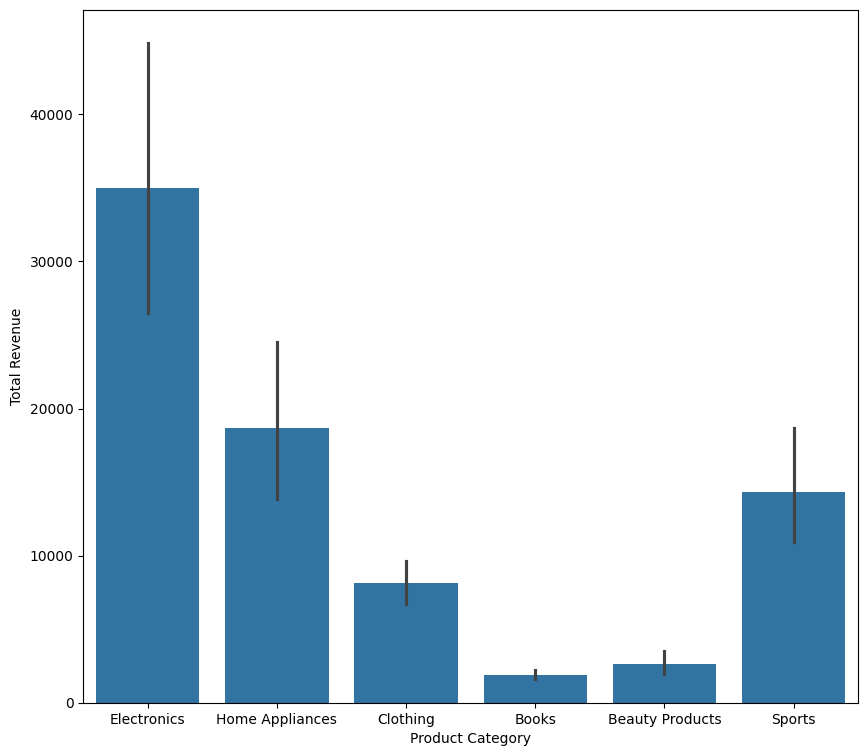

In [ ]:
# Seaborn can aggregate internally using estimator=sum
plt.figure(figsize=(10, 5))
sns.barplot(x='Product Category', y='Total Revenue', data=sales, estimator=sum)
plt.title('Total Revenue by Product Category (Seaborn)')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary
- **Scatter plot**: use to see relationship between two numeric variables.
- **Line plot**: use to show a trend or pattern as one variable changes.
- **Bar plot**: use to compare values across categories.
- **Box plot / Violin plot**: use to compare distributions and find outliers.
- **Histogram / KDE**: use to understand the shape of a single numeric variable.
- **Pair plot / Heatmap**: use to explore multiple variables at once.
- **Seaborn vs Matplotlib**: Seaborn can handle aggregation and style automatically, while Matplotlib gives lower-level control.